In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

In [64]:
df = pd.read_csv("CreditCardData.csv")
df.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [65]:
df.info()
df.describe()
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  object 
 1   Date                    100000 non-null  object 
 2   Day of Week             100000 non-null  object 
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  object 
 5   Entry Mode              100000 non-null  object 
 6   Amount                  99994 non-null   object 
 7   Type of Transaction     100000 non-null  object 
 8   Merchant Group          99990 non-null   object 
 9   Country of Transaction  100000 non-null  object 
 10  Shipping Address        99995 non-null   object 
 11  Country of Residence    100000 non-null  object 
 12  Gender                  99996 non-null   object 
 13  Age                     100000 non-null  float64
 14  Bank                 

In [ ]:
df_small = df[['Amount', 'Type of Transaction', 'Entry Mode', 'Time', 'Country of Transaction', 'Fraud']]
df_small.head()

,Amount,Type of Transaction,Entry Mode,Time,Country of Transaction,Fraud
0,£5,POS,Tap,19,United Kingdom,0
1,£288,POS,PIN,17,USA,0
2,£5,POS,Tap,14,India,0
3,£28,POS,Tap,14,United Kingdom,0
4,£91,Online,CVC,23,USA,1


In [ ]:
print("Missing Fraud labels before cleaning:", df['Fraud'].isna().sum())
df = df.dropna(subset=['Fraud'])
df['Fraud'] = df['Fraud'].astype(int)
print("Missing Fraud labels after cleaning:", df['Fraud'].isna().sum())

Missing Fraud labels before cleaning: 0
Missing Fraud labels after cleaning: 0


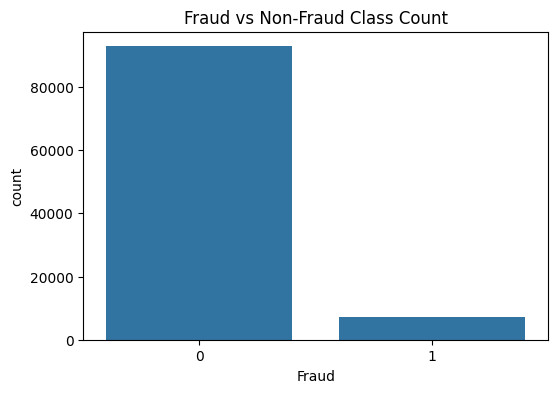

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_small, x="Fraud")
plt.title("Fraud vs Non-Fraud Class Count")
plt.show()

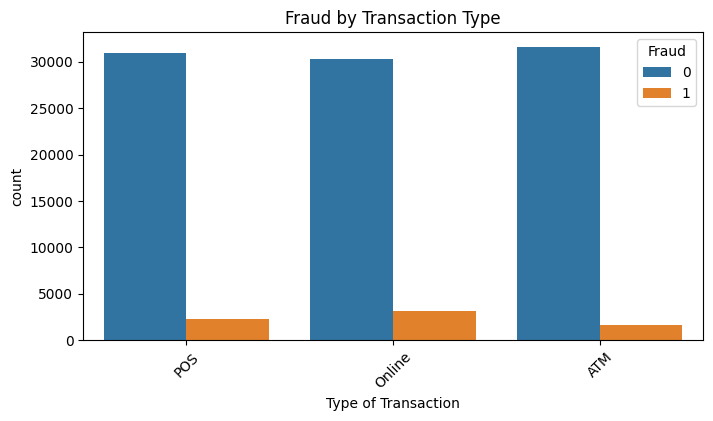

In [69]:
plt.figure(figsize=(8,4))
sns.countplot(data=df_small, x="Type of Transaction", hue="Fraud")
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

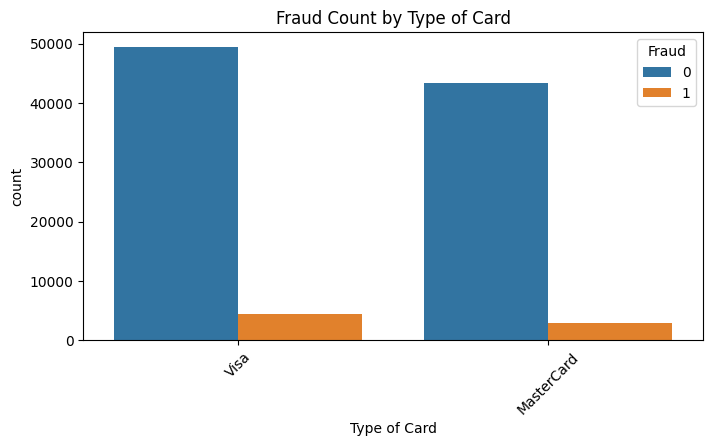

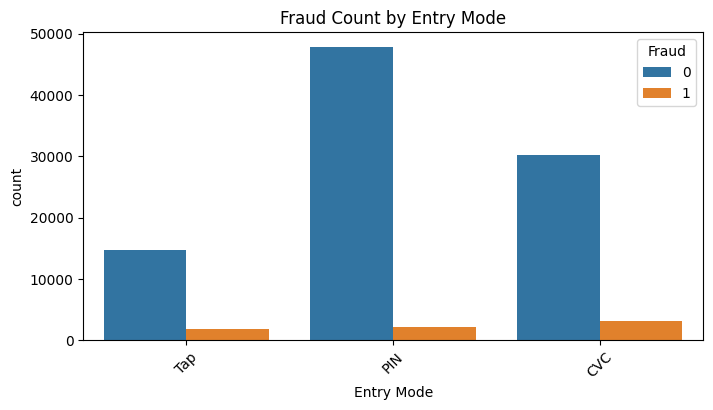

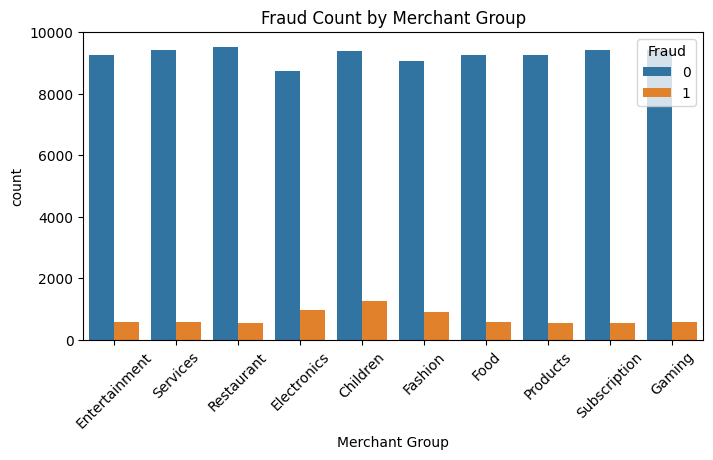

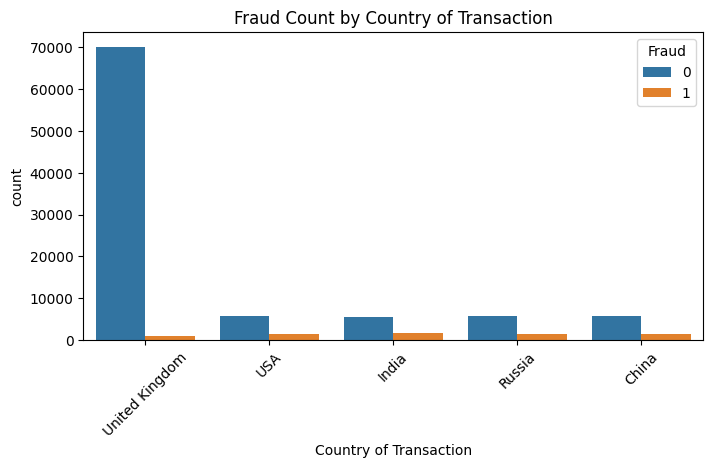

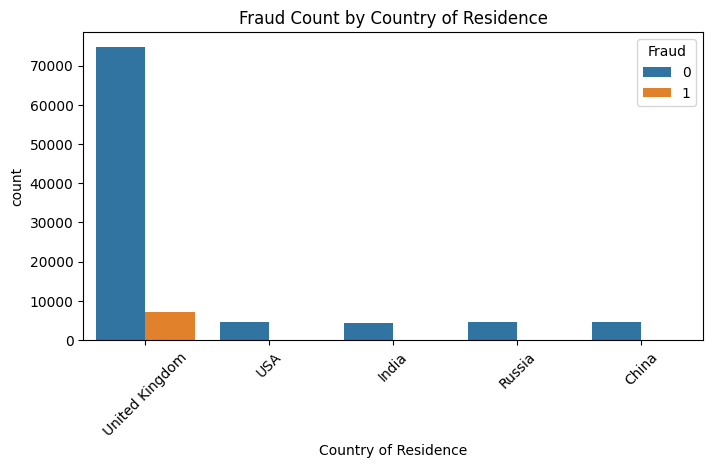

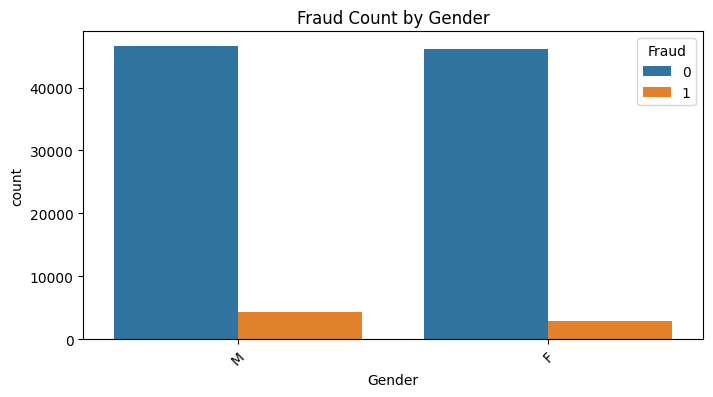

In [ ]:
cat_cols = ['Type of Card', 'Entry Mode', 'Merchant Group', 'Country of Transaction', 'Country of Residence', 'Gender']
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Fraud', data=df)
    plt.title(f"Fraud Count by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
print("Numeric Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numeric Columns: ['Time', 'Age']
Categorical Columns: ['Transaction ID', 'Date', 'Day of Week', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Bank']


In [ ]:
df['Amount'] = (
    df['Amount']
    .astype(str)
    .str.replace(r'[^0-9\.]', '', regex=True)
    .replace('', '0')
    .astype(float)
)
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df[['Amount','Age','Time']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Amount  100000 non-null  float64
 1   Age     100000 non-null  float64
 2   Time    100000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 2.3 MB


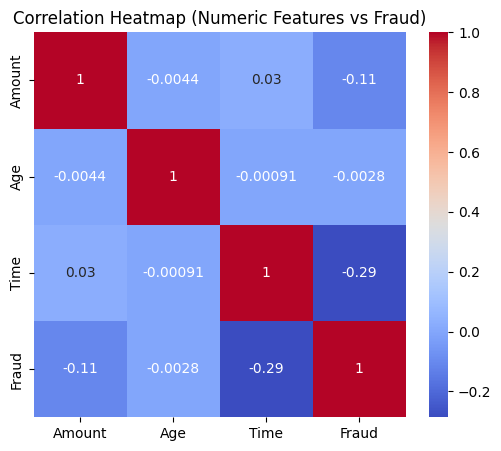

In [ ]:
num_cols = ['Amount','Age','Time']
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols + ['Fraud']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features vs Fraud)")
plt.show()

In [ ]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['Time', 'Amount', 'Age'], dtype='object')
Index(['Transaction ID', 'Date', 'Day of Week', 'Type of Card', 'Entry Mode',
       'Type of Transaction', 'Merchant Group', 'Country of Transaction',
       'Shipping Address', 'Country of Residence', 'Gender', 'Bank'],
      dtype='object')


In [80]:
preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

Logistic Regression Results

Accuracy: 0.9727
Precision: 0.8453209590100541
Recall: 0.7595552466990966
F1 Score: 0.8001464128843339
ROC-AUC: 0.9825604801986604

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     18561
           1       0.85      0.76      0.80      1439

    accuracy                           0.97     20000
   macro avg       0.91      0.87      0.89     20000
weighted avg       0.97      0.97      0.97     20000



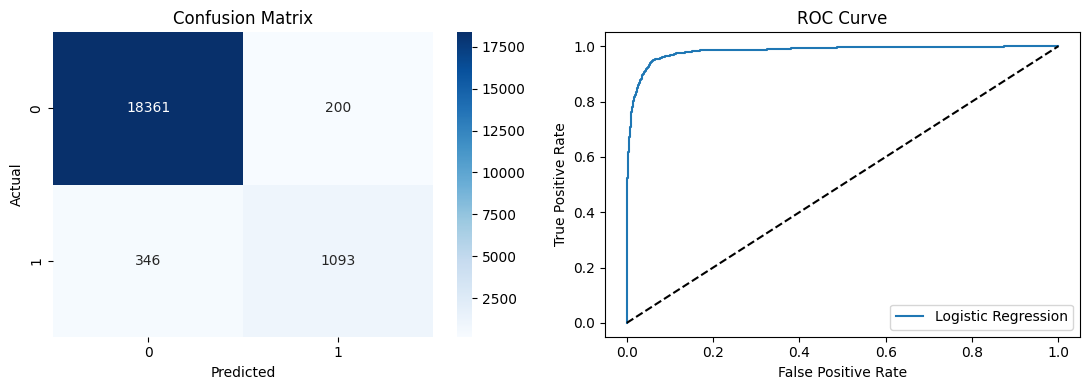

In [ ]:
log_pipeline = Pipeline([
    ('preprocess', preprocessor_base),
    ('model', LogisticRegression(max_iter=500))
])
log_pipeline.fit(X_train, y_train)
lr_pred = log_pipeline.predict(X_test)
lr_prob = log_pipeline.predict_proba(X_test)[:,1]
print("Logistic Regression Results\n")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))
cm = confusion_matrix(y_test, lr_pred)
fpr, tpr, _ = roc_curve(y_test, lr_prob)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[1].plot(fpr, tpr, label='Logistic Regression')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

Decision Tree Results

Accuracy: 0.9739
Precision: 0.7825015403573629
Recall: 0.8825573314801946
F1 Score: 0.829523187459177
ROC-AUC: 0.931769479812615

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99     18561
           1       0.78      0.88      0.83      1439

    accuracy                           0.97     20000
   macro avg       0.89      0.93      0.91     20000
weighted avg       0.98      0.97      0.97     20000



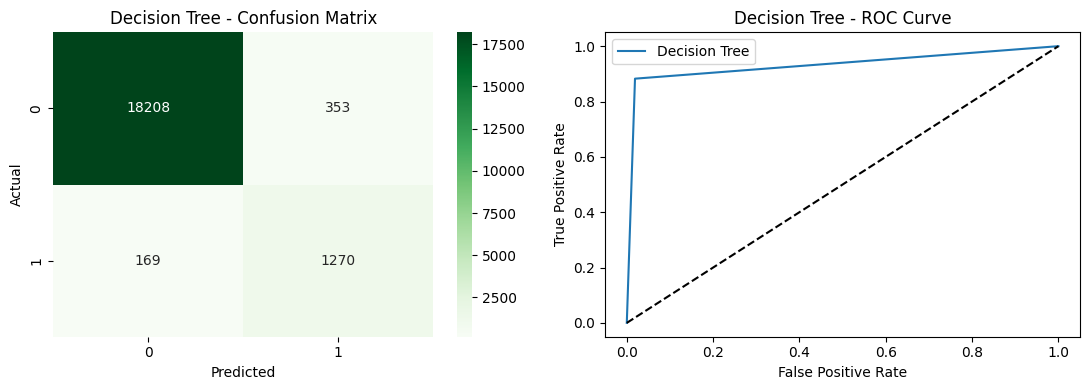

In [ ]:
dt_pipeline = Pipeline([
    ('preprocess', preprocessor_base),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])
dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
dt_prob = dt_pipeline.predict_proba(X_test)[:,1]
print("Decision Tree Results\n")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, dt_prob))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))
cm = confusion_matrix(y_test, dt_pred)
fpr, tpr, _ = roc_curve(y_test, dt_prob)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[1].plot(fpr, tpr, label='Decision Tree')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("Decision Tree - ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

Random Forest Results

Accuracy: 0.97905
Precision: 0.9913294797687862
Recall: 0.715079916608756
F1 Score: 0.8308437626160678
ROC-AUC: 0.9922649166231706

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     18561
           1       0.99      0.72      0.83      1439

    accuracy                           0.98     20000
   macro avg       0.98      0.86      0.91     20000
weighted avg       0.98      0.98      0.98     20000



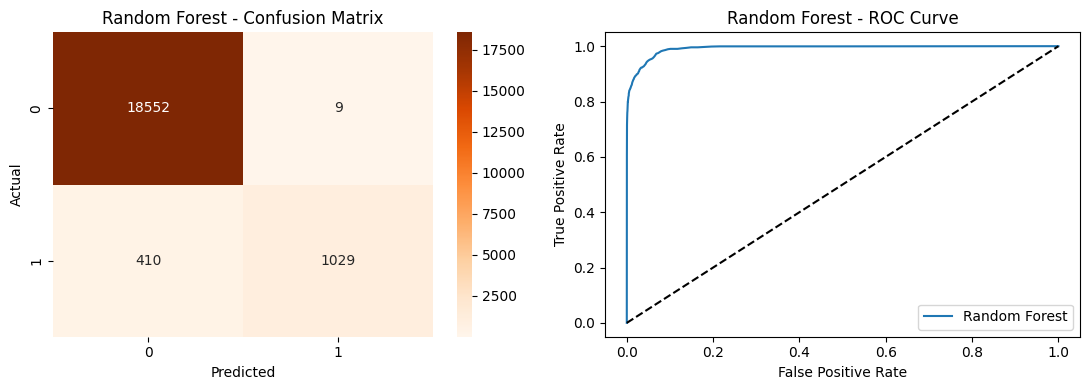

In [ ]:
rf_pipeline = Pipeline([
    ('preprocess', preprocessor_base),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]
print("Random Forest Results\n")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
cm = confusion_matrix(y_test, rf_pred)
fpr, tpr, _ = roc_curve(y_test, rf_prob)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title("Random Forest - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[1].plot(fpr, tpr, label='Random Forest')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("Random Forest - ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

XGBoost Results

Accuracy: 0.98555
Precision: 0.9471228615863142
Recall: 0.846421125781793
F1 Score: 0.8939449541284403
ROC-AUC: 0.9933712175457824

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     18561
           1       0.95      0.85      0.89      1439

    accuracy                           0.99     20000
   macro avg       0.97      0.92      0.94     20000
weighted avg       0.99      0.99      0.99     20000



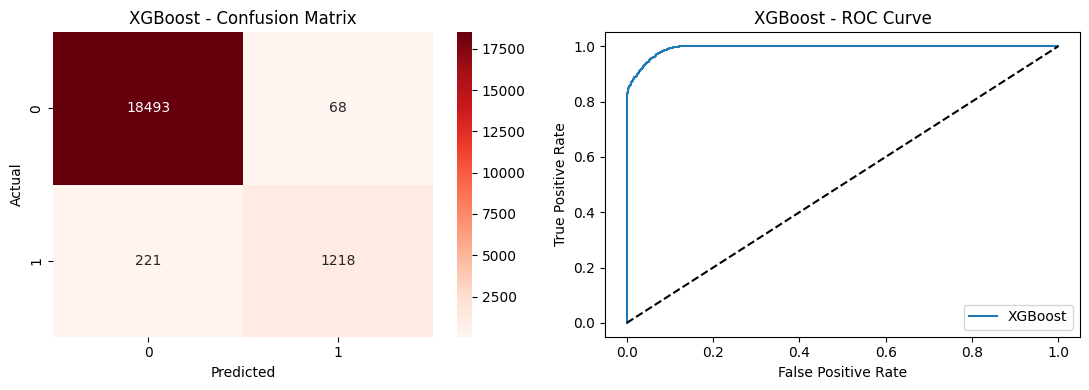

In [ ]:
xgb_pipeline = Pipeline([
    ('preprocess', preprocessor_base),
    ('model', xgb.XGBClassifier(
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]
print("XGBoost Results\n")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))
cm = confusion_matrix(y_test, xgb_pred)
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title("XGBoost - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[1].plot(fpr, tpr, label='XGBoost')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("XGBoost - ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("/content/Adv_IDS Project/models", exist_ok=True)

In [ ]:
joblib.dump(xgb_pipeline, "/content/Adv_IDS Project/models/xgboost_model.pkl")

In [ ]:
from google.colab import files
files.download("/content/Adv_IDS Project/models/xgboost_model.pkl")